In [1]:
import numpy as np
import pandas as pd

In [2]:
from Data.data_cleaning import Datacleaner

cleaner = Datacleaner("./Data/ligue1_2010_2025.csv")

cleaner = (cleaner.drop_useless_columns()
           .drop_rows(row_idxs=[1520,2281]) # ,2607
           .fillNA(column='Div',value='F1')
           .fillNA(column='Time', value='00:00')
           .add_season())

cleaner.save_data("Data/Dataset_clean_v3.csv")

c:\Leo_Perso\ENSAE\3A\Advanced ML\Projet ML\Learning-Latent-Football-Team-Strengths\Data\data_cleaning.py:26: DtypeWarning: Columns (139) have mixed types. Specify dtype option on import or set low_memory=False.
  self.df = pd.read_csv(filepath)


In [2]:
from Data.data_processing import DataProcesser

processer = DataProcesser("Data/Dataset_clean_v2.csv")

processer.remove_year("25-26")


# Seasons 2010-11 to 2023-24 in train, season 2024-25 in test
train_df, test_df = processer.split_train_test(test_size=306)

train_data, test_data = processer.get_train_test_data()

In [3]:
from BradleyTerry_classical.functions import BT_calibrate

# Calibrate Hyperparameter Lambda

Lambda_Chooser = BT_calibrate(train_data=train_data)

lambda_grid = np.linspace(-3,2,30)

Lambda_Chooser.calibrate_lambda(lambda_grid=lambda_grid)

Tolerance threshold attained after 234 iterations
Model fitted successfully !
Tolerance threshold attained after 236 iterations
Model fitted successfully !


KeyboardInterrupt: 

In [3]:
from BradleyTerry_classical.BT_classical import BradleyTerry

# Train the model
bt_model = BradleyTerry(lambda_draw=-0.24, learning_rate=0.01, n_iterations=1000)
bt_model.fit(train_data=train_data)

strength = bt_model.predict_strength()

Tolerance threshold attained after 333 iterations
Model fitted successfully !


In [6]:
from old_files.NeuralBT import NeuralBradleyTerry
import torch

# ==============================================================================
# 2. CHARGEMENT ET PRÉPARATION DES DONNÉES
# ==============================================================================
# On charge le fichier final créé précédemment
df = pd.read_csv("Data/dataset_training.csv")

# Liste des features (Assurez-vous que ces colonnes existent dans votre CSV)
# Note : on utilise les noms de base, on rajoutera _Home et _Away après
feature_names = [
    'Log_Market_Value',      # Structurel
    'Strength_Rank_Based',   # Historique
    'Pythagorean_Exp',       # Forme théorique
    'Avg_Goals_Scored',      # Attaque
    'Home_Dependency'        # Domicile
]

# Création des matrices X_home, X_away et y
# On prend toutes les données (Train + Test mélangés pour cet exemple simple)
X_home = df[[f"{col}_Home" for col in feature_names]].values.astype(np.float32)
X_away = df[[f"{col}_Away" for col in feature_names]].values.astype(np.float32)
y = df['Target'].values.astype(np.float32)

# ==============================================================================
# 3. ENTRAÎNEMENT
# ==============================================================================
model = NeuralBradleyTerry(input_dim=len(feature_names))
model.fit(X_home, X_away, y, epochs=500)

# ==============================================================================
# 4. OBTENIR LES FORCES (Ce que vous demandez)
# ==============================================================================

def get_season_ranking(model, df_full, target_season, feature_cols):
    """
    Extrait les forces des équipes pour une saison précise.
    """
    # 1. On filtre pour garder une seule ligne par équipe pour cette saison
    # On utilise les infos "Home" pour avoir les stats de l'équipe
    unique_teams = df_full[df_full['Season'] == target_season].drop_duplicates(subset=['HomeTeam'])
    
    if unique_teams.empty:
        print(f"Aucune donnée trouvée pour la saison {target_season}")
        return None

    # 2. Préparation des features de ces équipes
    cols_home = [f"{col}_Home" for col in feature_cols]
    X_teams = unique_teams[cols_home].values.astype(np.float32)

    # 3. Le modèle prédit la force !
    model.eval()
    with torch.no_grad():
        strengths = model.forward(torch.tensor(X_teams)).numpy().flatten()
        
        strengths = strengths - np.mean(strengths)  # Centrage pour interprétation relative

        print(f"Moyennes des forces {np.mean(strengths)}")
    
    # 4. Création du tableau de résultat
    ranking = pd.DataFrame({
        'Team': unique_teams['HomeTeam'],
        'Neural_Strength': strengths
        })
    
        # On trie du plus fort au plus faible
    return ranking.sort_values(by='Neural_Strength', ascending=False)

# --- EXEMPLE : CLASSEMENT POUR LA DERNIÈRE SAISON DU FICHIER ---
last_season = '2024-2025' # Ex: "22-23" ou "2022" selon votre format
print(f"\n--- CLASSEMENT NEURAL POUR LA SAISON {last_season} ---")

ranking = get_season_ranking(model, df, last_season, feature_names)

ranking

Début de l'entraînement...
Epoch 0 | Loss: 0.6825
Epoch 50 | Loss: 0.6426
Epoch 100 | Loss: 0.6421
Epoch 150 | Loss: 0.6421
Epoch 200 | Loss: 0.6421
Epoch 250 | Loss: 0.6421
Epoch 300 | Loss: 0.6421
Epoch 350 | Loss: 0.6421
Epoch 400 | Loss: 0.6421
Epoch 450 | Loss: 0.6421
Entraînement terminé.

--- CLASSEMENT NEURAL POUR LA SAISON 2024-2025 ---
Aucune donnée trouvée pour la saison 2024-2025


In [4]:
strength

,Team,Strength
0,Ajaccio,-0.715132
1,Ajaccio GFCO,-0.408636
2,Amiens,-0.353454
3,Angers,-0.217858
4,Arles,-1.494393
5,Auxerre,-0.309198
6,Bastia,-0.099556
7,Bordeaux,0.278030
8,Brest,-0.074030
9,Caen,-0.269808


In [4]:
# Simulate ranking correlated with BT strengths

teams = pd.unique(test_df[['HomeTeam', 'AwayTeam']].values.ravel())
np.random.seed(42)

# Merge with strength to get BT strengths for these teams
team_strengths = pd.DataFrame({'Team': teams}).merge(strength, on='Team', how='left')

# Add correlated noise
noise = np.random.normal(0, 0.5, len(team_strengths))
sim_strengths = team_strengths['Strength'] + noise

sim_ranking = pd.DataFrame({
    'Team': teams,
    'Strength': sim_strengths
})
print(sim_ranking)

           Team  Strength
0      Le Havre -0.174915
1      Paris SG  1.948820
2         Brest  0.249814
3     Marseille  1.637167
4         Reims -0.010841
5         Lille  0.751965
6        Monaco  1.860875
7    St Etienne  0.795562
8       Auxerre -0.543935
9          Nice  0.735276
10       Angers -0.449567
11         Lens  0.167677
12  Montpellier  0.380082
13   Strasbourg -0.900860
14     Toulouse -0.990962
15       Nantes -0.262872
16       Rennes -0.069538
17         Lyon  1.107156


In [5]:
from Test.test_BT_classical import BT_evaluate_strengths

Evaluate = BT_evaluate_strengths(BT_results=strength, NBTR_results=sim_ranking, test_df=test_df)

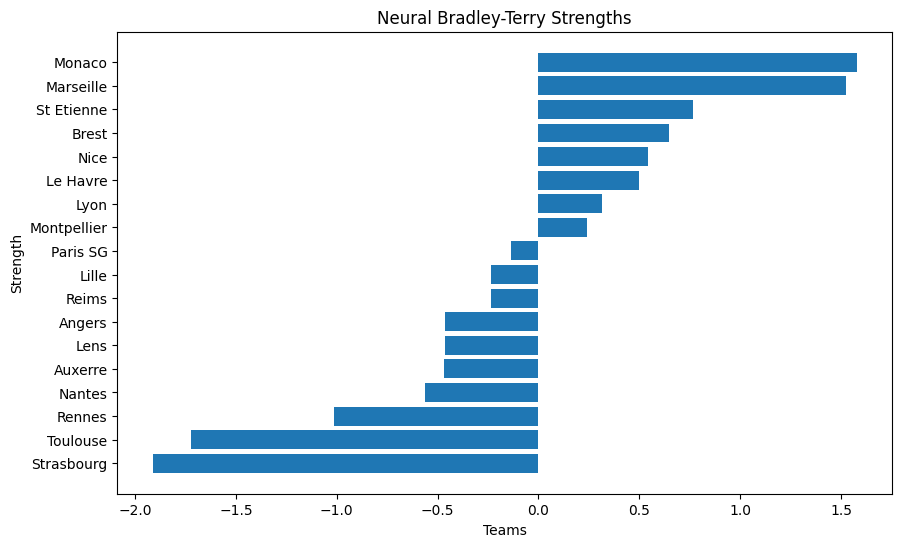

In [11]:
Evaluate.plot_strengths(model='NBTR')

In [9]:
Evaluate.spearman_correlation()

{'correlation': np.float64(0.6670128020188779),
 'pvalue': np.float64(0.002497188896711762),
 'ci_lower': np.float64(0.23712429580389305),
 'ci_upper': np.float64(0.9167090255721111)}

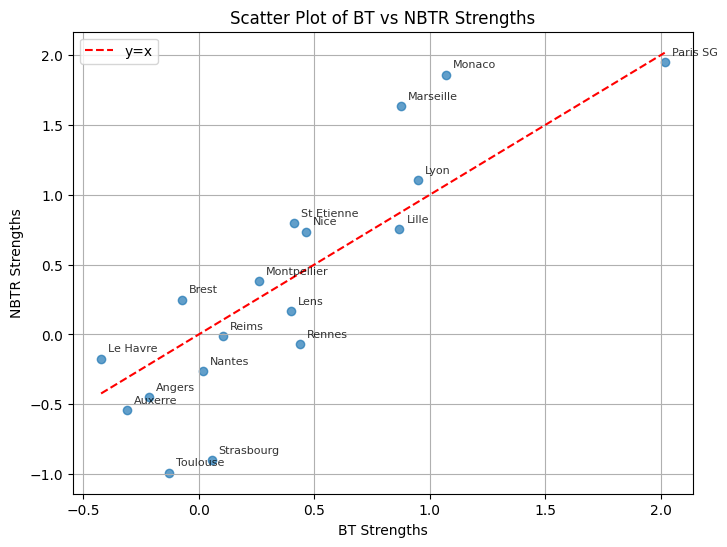

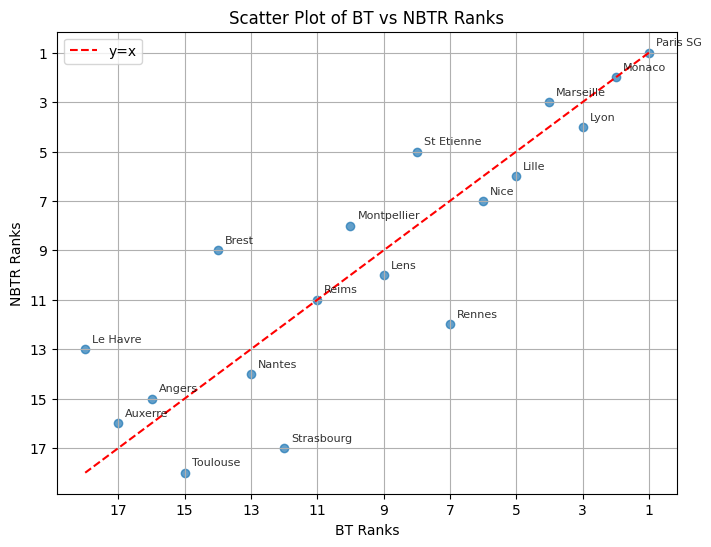

Pearson correlation: {'correlation': np.float64(0.8653806341424221), 'pvalue': np.float64(3.524604440109154e-06), 'ci_lower': np.float64(0.7608721992113614), 'ci_upper': np.float64(0.932868025360075)}
Spearman correlation: {'correlation': np.float64(0.8658410732714137), 'pvalue': np.float64(3.4345106049678616e-06), 'ci_lower': np.float64(0.6300805065256606), 'ci_upper': np.float64(0.9626651572038635)}
Results correlation (points, BT): {'correlation': np.float64(0.6390913358878553), 'pvalue': np.float64(0.004299097971605389), 'ci_lower': np.float64(0.173856141542416), 'ci_upper': np.float64(0.8775077895575488)}
Results correlation (points, NBTR): {'correlation': np.float64(0.4901768498557336), 'pvalue': np.float64(0.038912271024889165), 'ci_lower': np.float64(-0.12740914503546416), 'ci_upper': np.float64(0.8415861330439293)}


In [6]:
# Test all methods of BT_evaluate_strengths

# Plot strengths for BT
# Evaluate.plot_strengths('BT')

# Plot strengths for NBTR
# Evaluate.plot_strengths('NBTR')

# Scatter plot of strengths
Evaluate.plot_scatter_strengths()

# Scatter plot of ranks
Evaluate.plot_scatter_ranks()

# Pearson correlation
print("Pearson correlation:", Evaluate.pearson_correlation())

# Spearman correlation
print("Spearman correlation:", Evaluate.spearman_correlation())

# Results correlation for points
print("Results correlation (points, BT):", Evaluate.results_correlation('BT', 'points'))
print("Results correlation (points, NBTR):", Evaluate.results_correlation('NBTR', 'points'))

In [11]:
# Test BT_evaluate_probas

from Test.test_BT_classical import BT_evaluate_probas

# BT_results: simulate season
teams = pd.unique(test_df[['HomeTeam', 'AwayTeam']].values.ravel())
BT_results = bt_model.simulate_season(teams)

# NBTR_results: load from CSV and add Result
NBTR_results = pd.read_csv('Data/Predictions_24-25.csv')

# Add Result column based on probabilities
def determine_result(row):
    p_home = row['P_Home']
    p_draw = row['P_Draw']
    p_away = row['P_Away']
    if p_home > p_draw and p_home > p_away:
        return 'H'
    elif p_draw > p_away:
        return 'D'
    else:
        return 'A'

NBTR_results['Result'] = NBTR_results.apply(determine_result, axis=1)

# Create evaluator
evaluator_probas = BT_evaluate_probas(BT_results=BT_results, NBTR_results=NBTR_results, test_df=test_df)

print("BT_evaluate_probas created successfully")


BT_evaluate_probas created successfully


In [24]:
evaluator_probas.NBTR_results

,HomeTeam,AwayTeam,P_Home,P_Draw,P_Away,Strength_Diff,Result
0,Le Havre AC,Stade Brestois 29,0.389415,0.244774,0.365811,-0.249770,H
1,Le Havre AC,Stade Reims,0.313403,0.240324,0.446272,-0.584257,A
2,Le Havre AC,AS Monaco,0.204574,0.206882,0.588543,-1.157947,A
3,Le Havre AC,AJ Auxerre,0.373551,0.244902,0.381547,-0.317011,A
4,Le Havre AC,Angers SCO,0.456614,0.238898,0.304488,0.026017,H
...,...,...,...,...,...,...,...
301,Olympique Marseille,AS Saint-Étienne,0.637702,0.189426,0.172873,0.765402,H
302,Olympique Marseille,RC Lens,0.520925,0.226278,0.252797,0.283751,H
303,Olympique Marseille,FC Nantes,0.568387,0.213257,0.218356,0.475274,H
304,Olympique Marseille,OGC Nice,0.507926,0.229321,0.262754,0.231705,H


In [14]:
# Test all methods of BT_evaluate_probas

print("Log-loss BT:", evaluator_probas.logloss('BT'))
print("Log-loss NBTR:", evaluator_probas.logloss('NBTR'))

print("Accuracy BT:", evaluator_probas.accuracy('BT'))
print("Accuracy NBTR:", evaluator_probas.accuracy('NBTR'))

print("Recall BT:", evaluator_probas.recall('BT'))
print("Recall NBTR:", evaluator_probas.recall('NBTR'))

print("Precision BT:", evaluator_probas.precision('BT'))
print("Precision NBTR:", evaluator_probas.precision('NBTR'))

print("Brier score BT:", evaluator_probas.brier_score('BT'))
print("Brier score NBTR:", evaluator_probas.brier_score('NBTR'))

# Reliability curve (without plotting)
curve_bt = evaluator_probas.reliability_curve_draw('BT', plot=False)
print("Reliability curve BT shape:", curve_bt.shape)

curve_nbtr = evaluator_probas.reliability_curve_draw('NBTR', plot=False)
print("Reliability curve NBTR shape:", curve_nbtr.shape)

# Optional: plot reliability curve
evaluator_probas.reliability_curve_draw('BT', plot=True)

ZeroDivisionError: division by zero